# Notes

#### Log

- VMD-LSTM Performance was at $r^2 = 0.9555$ using `best_alpha, best_K = 0, 3` and normal power to produce IMFs.
- Using log-power allowed the performance to increase to $r^2 = 0.9644$ using `best_alpha, best_K = 4213.6, 10`.
- We experimented with L2 weight decay in the Adam optimizer but observed a substantial deterioration in R², suggesting that the VMD decomposition plus dropout and early stopping already provide sufficient regularisation, and additional L2 penalisation forces the LSTMs to underfit the decomposed components.
- Fixed solar encoding alignment. Standard LSTM $r^2 = 0.9893$, VMD LSTM $r^2 = 0.9532$.
- For above `best_alpha, best_K = 4213.6, 10`. Attempting to reduce LSTM error impact whilst keeping IMF benefits by reducing K bounds for genetic algorithm. 
<br>

- Broken sequencing, gaps present. Before fixing: <br>
Naive Baseline (guesses using yesterdays value):
RMSE: 3487.3308
R²: 0.5983<br>
LSTM Model:
RMSE: 558.5315
R²: 0.9897<br>
VMD LSTM Ensemble:
RMSE: 287.8001
R²: 0.9973<br>

- After fixing: <br>
Naive Baseline (guesses using yesterdays value):
  RMSE: 3379.7084
  R²: 0.6304<br>
LSTM Model:
  RMSE: 476.9674
  R²: 0.9926<br>
VMD LSTM Ensemble:
  RMSE: 158.3118
  R²: 0.9992<br>

- After 48/24, identified linear output head as a bottleneck for long-horizon predictions. Using a single matrix multiplication to project hidden state to 24 outputs does not grant the model any mechanism by which to construct qualitatively different representations for near vs far horizons.

#### Horizon 6h, Lookback 24h
epoch 150 else 100

#### Horizon 12h, Lookback 36h
epoch 250 else 200

#### Horizon 24h, Lookback 48h
epoch 300 else 250

# Preamble
---
This section imports all relevant libraries and defines all data loading functions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import glob
from pathlib import Path
import re

import pvlib
from scipy.signal import hilbert
from scipy import stats
from vmdpy import VMD

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LinearRegression

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss
import lightning.pytorch as pl

In [2]:
def load_weather_files(folder_path):
    """Load weather files and merge by timestamp"""
    
    # Get all files
    csv_files = glob.glob(f"{folder_path}/**/*.csv", recursive=True)
    xlsx_files = glob.glob(f"{folder_path}/**/*.xlsx", recursive=True)
    all_files = sorted(csv_files + xlsx_files)
    
    print(f"Found {len(all_files)} weather files\n")

    # Group files by parameter
    param_dfs = {}
    
    for file_path in all_files:
        filename = Path(file_path).stem  # e.g., "Irradiance_2021"
        
        # Extract parameter name (everything before last underscore)
        parts = filename.split('_')
        param_name = '_'.join(parts[:-1])  # e.g., "Irradiance", "Relative Humidity"

        # Load file
        try:
            if file_path.endswith('.csv'):
                df = pd.read_csv(file_path, parse_dates=['Time'])
            else:
                df = pd.read_excel(file_path, parse_dates=['Time'])
            
            print(f"✓ Loaded {Path(file_path).name}")
            
            # Append to parameter's list
            if param_name not in param_dfs:
                param_dfs[param_name] = []
            param_dfs[param_name].append(df)
            
        except Exception as e:
            print(f"✗ Failed {Path(file_path).name}: {e}")

    print(f"\nProcessing {len(param_dfs)} parameters...")
    
    merged_params = []
    
    for param_name, yearly_dfs in param_dfs.items():
        # Concatenate years
        param_all_years = pd.concat(yearly_dfs, ignore_index=True)
        
        # Get value column (the other column that's not 'Time')
        value_col = [c for c in param_all_years.columns if c != 'Time'][0]
        
        # Rename value column to clean parameter name
        clean_param_name = param_name.lower().replace(' ', '_')
        param_all_years = param_all_years.rename(columns={value_col: clean_param_name})
        
        # Keep only timestamp and value
        param_all_years = param_all_years[['Time', clean_param_name]]
        
        merged_params.append(param_all_years)
        print(f"  ✓ {param_name}: {len(param_all_years)} rows")
    
    # Merge all parameters
    print("\nMerging all parameters on Time...")
    weather_full = merged_params[0]
    
    for param_df in merged_params[1:]:
        weather_full = weather_full.merge(param_df, on='Time', how='outer')
    
    weather_full = weather_full.sort_values('Time').reset_index(drop=True)
    
    print(f"\n✓ Final merged dataset: {weather_full.shape}")
    print(f"  Columns: {weather_full.columns.tolist()}")
    print(f"  Date range: {weather_full['Time'].min()} to {weather_full['Time'].max()}")
    
    return weather_full
##################################################################################################
def load_pv_data(pv_folder):
    """Load all PV stations with optimizer type tracked"""
    
    # Find files in both folders
    with_opt_files = glob.glob(
        f"{pv_folder}/PV stations with panel level optimizer/Site level dataset/*.csv"
    )
    without_opt_files = glob.glob(
        f"{pv_folder}/PV stations without panel level optimizer/Site level dataset/*.csv"
    )
    
    print(f"Loading PV data:")
    print(f"  With optimizer: {len(with_opt_files)}")
    print(f"  Without optimizer: {len(without_opt_files)}\n")
    
    dfs = []  # ← Changed from {} to []
    optimizer_info = {}
    
    # Load WITH optimizer
    for file_path in sorted(with_opt_files):
        filename = Path(file_path).stem
        df = pd.read_csv(file_path, parse_dates=['Time'])
        
        # Keep Time and rename power column to station ID
        df = df[['Time', 'power(W)']].rename(columns={'power(W)': filename})
        #Guard against duplicate rows
        df = df.groupby('Time', as_index=False).mean()
        dfs.append(df)
        
        optimizer_info[filename] = True
        print(f"✓ {filename} (with optimizer)")
    
    # Load WITHOUT optimizer
    for file_path in sorted(without_opt_files):
        filename = Path(file_path).stem
        df = pd.read_csv(file_path, parse_dates=['Time'])
        
        # Keep Time and rename power column to station ID
        df = df[['Time', 'power(W)']].rename(columns={'power(W)': filename})
        #Guard against duplicate rows
        df = df.groupby('Time', as_index=False).mean()
        dfs.append(df)
        
        optimizer_info[filename] = False
        print(f"✓ {filename} (without optimizer)")
        
    # Before merging, inspect each station's time range
    print("\nData availability by station:")
    for i, df in enumerate(dfs):
        print(f"  Station {i}: {df['Time'].min()} to {df['Time'].max()}")
        
    # Merge all on Time (same as weather function)
    print("\nMerging all stations on Time...")
    pv_wide = dfs[0]
    
    for df in dfs[1:]:
        pv_wide = pv_wide.merge(df, on='Time', how='outer')
    
    pv_wide = pv_wide.sort_values('Time').reset_index(drop=True)
    
    print(f"\n✓ Combined PV data (wide format):")
    print(f"  Shape: {pv_wide.shape}")
    print(f"  Rows (timestamps): {len(pv_wide)}")
    print(f"  Columns: {pv_wide.shape[1]} (timestamp + {pv_wide.shape[1] - 1} stations)")
    
    return pv_wide, optimizer_info
#################################################################################################
def load_metadata(filename):
    #Read the TTL file
    with open(filename, 'r', encoding='utf-8') as f:
        lines = f.readlines()
    
    # Parse station blocks line by line
    stations_data = []
    current_station = None
    current_block = []
    
    for line in lines:
        # Start of a new station
        if 'a brick:PV_Generation_System' in line:
            # Save previous station if exists
            if current_station and current_block:
                stations_data.append((current_station, '\n'.join(current_block)))
            
            # Extract station name
            match = re.search(r'pvsystem:(\S+)\s+a\s+brick:PV_Generation_System', line)
            if match:
                current_station = match.group(1)
                current_block = [line]
        elif current_station:
            current_block.append(line)
            # End of station block (when next station or inverter starts)
            if line.strip().startswith('pvsystem:') and 'a brick:PV_Generation_System' not in line and 'a brick:Inverter' in line:
                stations_data.append((current_station, '\n'.join(current_block)))
                current_station = None
                current_block = []
    
    # Add last station
    if current_station and current_block:
        stations_data.append((current_station, '\n'.join(current_block)))
    
    # Extract metadata from each station block
    metadata_list = []
    for station_name, block in stations_data:
        station_dict = {'station_id': station_name}
        
        # Latitude
        match = re.search(r'brick:latitude\s+([\d.]+)', block)
        if match:
            station_dict['latitude'] = float(match.group(1))
        
        # Longitude
        match = re.search(r'brick:longitude\s+([\d.]+)', block)
        if match:
            station_dict['longitude'] = float(match.group(1))
        
        # Location
        match = re.search(r'brick:hasLocation\s*\[\s*brick:value\s*"([^"]+)"', block)
        if match:
            station_dict['location'] = match.group(1)
        
        # Altitude
        match = re.search(r'ext:altitude\s*\[.*?brick:value\s+([\d.]+)', block, re.DOTALL)
        if match:
            station_dict['altitude_m'] = float(match.group(1))
        
        # Capacity (ratedPowerOutput)
        match = re.search(r'ext:ratedPowerOutput\s*\[.*?brick:value\s+([\d.]+)', block, re.DOTALL)
        if match:
            station_dict['capacity_kw'] = float(match.group(1))
        
        # Azimuth
        match = re.search(r'ext:azimuth\s*\[\s*brick:value\s*"([^"]+)"', block)
        if match:
            station_dict['azimuth'] = match.group(1)
        
        # Tilt angle
        match = re.search(r'ext:tiltAngle\s*\[\s*brick:value\s*"([^"]+)"', block)
        if match:
            station_dict['tilt_angle'] = match.group(1)
        
        # Connection date
        match = re.search(r'ext:connectionDate\s*\[\s*brick:value\s*"([^"]+)"', block)
        if match:
            station_dict['connection_date'] = match.group(1)
        
        # Contractor
        match = re.search(r'ext:contractor\s*\[\s*brick:value\s*"([^"]+)"', block)
        if match:
            station_dict['contractor'] = match.group(1)
        
        metadata_list.append(station_dict)
    
    # Create DataFrame
    df = pd.DataFrame(metadata_list)
    
    # Display results
    print(f"✓ Extracted metadata for {len(df)} stations")
    print(f"\nColumns: {list(df.columns)}")
    print(f"\nCapacity range: {df['capacity_kw'].min():.1f} - {df['capacity_kw'].max():.1f} kW")
    print(f"Total capacity: {df['capacity_kw'].sum():.2f} kW")
    print(f"\nMissing values:\n{df.isnull().sum()}")
    
    return df

# Preprocessing
---
This section handles the loading of both weather and PV data into dataframes. Both datasets are resampled to 15 minute increments in order to match increments across both data sets and the whole time range.<br>
The resulting dataset will have no weather NaNs, and columns for PV for each solar panel. This will allow for flexibility in choosing which panel we wish to train the LSTM on (stage 1).

#### Loading Weather Files 
First, we load the weather files using `load_weather_files`.

In [3]:
weather_data = load_weather_files("Meteorological dataset") #folder_path
weather_data = weather_data.set_index('Time')  # Set timestamp as index (required for resample)
print("\n" + "="*60)
print(weather_data.head(10))
print("\nData types:")
print(weather_data.dtypes)

Found 21 weather files

✓ Loaded Irradiance_2021.csv
✓ Loaded Irradiance_2022.csv
✓ Loaded Irradiance_2023.csv
✓ Loaded Rainfall_2021.xlsx
✓ Loaded Rainfall_2022.csv
✓ Loaded Rainfall_2023.csv
✓ Loaded Relative Humidity_2021.csv
✓ Loaded Relative Humidity_2022.csv
✓ Loaded Relative Humidity_2023.csv
✓ Loaded Sea Level Pressure_2021.csv
✓ Loaded Sea Level Pressure_2022.csv
✓ Loaded Sea Level Pressure_2023.csv
✓ Loaded Temperature_2021.csv
✓ Loaded Temperature_2022.csv
✓ Loaded Temperature_2023.csv
✓ Loaded Visibility_2021.csv
✓ Loaded Visibility_2022.csv
✓ Loaded Visibility_2023.csv
✓ Loaded Wind_2021.csv
✓ Loaded Wind_2022.csv
✓ Loaded Wind_2023.csv

Processing 7 parameters...
  ✓ Irradiance: 1567792 rows
  ✓ Rainfall: 1567792 rows
  ✓ Relative Humidity: 1567665 rows
  ✓ Sea Level Pressure: 1567792 rows
  ✓ Temperature: 1567712 rows
  ✓ Visibility: 1567792 rows
  ✓ Wind: 1567175 rows

Merging all parameters on Time...

✓ Final merged dataset: (1567792, 8)
  Columns: ['Time', 'irradianc

#### Loading PV Files
We load the pv data using `load_pv_data`. Note that stations have varied recording start dates. A dictionary is used to remember which stations used an optimizer.

In [4]:
pv_data, optimizer_info = load_pv_data("PV generation dataset") #pv_folder
pv_data = pv_data.set_index('Time')
power_features = list(pv_data.columns)
print("\n" + "="*60)
print(pv_data.head(10))
print(pv_data.dtypes)
print(optimizer_info)

Loading PV data:
  With optimizer: 37
  Without optimizer: 23

✓ Indoor Sports Centre (with optimizer)
✓ LSK North (with optimizer)
✓ LSK South (with optimizer)
✓ Library (with optimizer)
✓ S H Ho Sports Hall (with optimizer)
✓ SQ Apartment1-12 (with optimizer)
✓ SQ Apartment13-24 (with optimizer)
✓ SQ Apartment25-36 (with optimizer)
✓ SQ Apartment37-48 (with optimizer)
✓ SQ Block P (with optimizer)
✓ SQ Block R (with optimizer)
✓ SQ Block S (with optimizer)
✓ SQ1 (with optimizer)
✓ SQ2 (with optimizer)
✓ SQ3 (with optimizer)
✓ SQ4 (with optimizer)
✓ SQ567 (with optimizer)
✓ Shaw Auditorium (with optimizer)
✓ UG Hall2 2F (with optimizer)
✓ UG Hall2 RF (with optimizer)
✓ UG Hall3 (with optimizer)
✓ UG Hall4 (with optimizer)
✓ UG Hall6 (with optimizer)
✓ UG Hall7 (with optimizer)
✓ UG Hall8 (with optimizer)
✓ UG Hall9 (with optimizer)
✓ Wong Check She Research Centre (with optimizer)
✓ Zone A1 (with optimizer)
✓ Zone A2 (with optimizer)
✓ Zone A4 (with optimizer)
✓ Zone A5 (with optimize

#### Time Increment Resampling
Then, the both datasets are resampled to match time increments.

In [5]:
weather_60m = weather_data.resample('60min').mean() # Resample to 5-minute intervals (mean aggregation)
print(f"Original: {len(weather_data)} rows (1-minute)")
print(f"Resampled: {len(weather_60m)} rows (60-minute)")
print(weather_60m.head(10))

pv_data_60m = pv_data.resample('60min').mean()
print(f"Original: {len(pv_data)} rows (1-minute)")
print(f"Resampled: {len(pv_data_60m)} rows (60-minute)")
print(pv_data_60m.head(10))

Original: 1567792 rows (1-minute)
Resampled: 26280 rows (60-minute)
                     irradiance  rainfall  relative_humidity  \
Time                                                           
2021-01-01 00:00:00    2.523105       0.0          10.992917   
2021-01-01 01:00:00    2.243603       0.0          11.576567   
2021-01-01 02:00:00    2.000985       0.0          11.787583   
2021-01-01 03:00:00    1.986358       0.0          12.356500   
2021-01-01 04:00:00    1.986372       0.0          12.960367   
2021-01-01 05:00:00    1.986422       0.0          12.358267   
2021-01-01 06:00:00    2.203398       0.0          12.936567   
2021-01-01 07:00:00   47.010347       0.0          13.190400   
2021-01-01 08:00:00  251.567833       0.0           7.638452   
2021-01-01 09:00:00  422.195500       0.0           5.747887   

                     sea_level_pressure  temperature  visibility      wind  
Time                                                                        
2021-01-0

#### Joining Datasets and NaN Handling
Then, we join all data frames into one with time as an index.

In [6]:
df = weather_60m.join(pv_data_60m, how='inner') 
print(df.head(10))

                     irradiance  rainfall  relative_humidity  \
Time                                                           
2021-03-10 00:00:00    4.639122       0.0          76.729933   
2021-03-10 01:00:00    4.673955       0.0          76.763667   
2021-03-10 02:00:00    4.833763       0.0          79.332767   
2021-03-10 03:00:00    4.716148       0.0          76.912300   
2021-03-10 04:00:00    4.651888       0.0          73.599467   
2021-03-10 05:00:00    4.626110       0.0          72.401567   
2021-03-10 06:00:00    4.591393       0.0          67.686850   
2021-03-10 07:00:00    4.672165       0.0          66.634767   
2021-03-10 08:00:00    4.626248       0.0          63.941967   
2021-03-10 09:00:00    4.651837       0.0          60.238383   

                     sea_level_pressure  temperature  visibility      wind  \
Time                                                                         
2021-03-10 00:00:00         1008.729463    17.641750   10.324573  2.210078 

Lastly, we check for NaNs in weather and filter them out. This is essential for training the model, regardless of the station chosen. <br>
`create_sequences_multi` later on will guard against resulting time jumps in the data.

In [7]:
weather_features = ['irradiance', 
                    #'rainfall', 
                    'relative_humidity', 
                    #'sea_level_pressure', 
                    'temperature' 
                    #'visibility', 
                    #'wind'
                   ]

# Find rows with ANY NaN in weather features
weather_has_nan = df[weather_features].isna().any(axis=1)

if weather_has_nan.any():  
    # Drop all rows with NaN in weather features cols
    df = df[~weather_has_nan].copy()
    print(f"✓ Dropped {weather_has_nan.sum()} rows with NaN weather. New shape: {df.shape}")
else:
    print("✓ No rows with NaN weather features")

# Verify
print(f"Weather NaNs remaining: \n{df[weather_features].isna().sum()}")
# Check monthly distribution after cleaning
df['year_month'] = df.index.to_period('M')
monthly = df.groupby('year_month').size()
print("\nMonthly distribution after cleaning:")
print(monthly)

✓ Dropped 147 rows with NaN weather. New shape: (24501, 67)
Weather NaNs remaining: 
irradiance           0
relative_humidity    0
temperature          0
dtype: int64

Monthly distribution after cleaning:
year_month
2021-03    528
2021-04    720
2021-05    744
2021-06    720
2021-07    744
2021-08    744
2021-09    720
2021-10    744
2021-11    720
2021-12    744
2022-01    739
2022-02    672
2022-03    744
2022-04    720
2022-05    744
2022-06    720
2022-07    744
2022-08    744
2022-09    720
2022-10    744
2022-11    720
2022-12    700
2023-01    744
2023-02    672
2023-03    744
2023-04    720
2023-05    744
2023-06    720
2023-07    744
2023-08    744
2023-09    622
2023-10    744
2023-11    720
2023-12    744
Freq: M, dtype: int64


#### Data Availability Investigation
This final cell outputs information on the processed data sets.

In [8]:
# ============================================================================
# DATA AVAILABILITY INVESTIGATION
# ============================================================================

print("="*70)
print("CHECKING RAW DATA AVAILABILITY")
print("="*70)

# 1. Check weather_15m
print("\n1. weather_15m:")
print(f"   Date range: {weather_60m.index.min()} to {weather_60m.index.max()}")
print(f"   Total rows: {len(weather_60m)}")
print(f"   Expected rows (hourly): {((weather_60m.index.max() - weather_60m.index.min()).days + 1) * 24}")

weather_60m['year_month'] = weather_60m.index.to_period('M')
weather_by_month = weather_60m.groupby('year_month').size()
print("\n   Samples per month:")
print(weather_by_month)

# Check for gaps
weather_60m_sorted = weather_60m.sort_index()
time_diffs = weather_60m_sorted.index.to_series().diff()
large_gaps = time_diffs[time_diffs > pd.Timedelta(hours=2)]
print(f"\n   Gaps > 2 hours: {len(large_gaps)}")
if len(large_gaps) > 0:
    print("   First 5 large gaps:")
    print(large_gaps.head())

# 2. Check pv_data_15m
print("\n" + "="*70)
print("2. pv_data_15m:")
print(f"   Date range: {pv_data_60m.index.min()} to {pv_data_60m.index.max()}")
print(f"   Total rows: {len(pv_data_60m)}")

pv_data_60m['year_month'] = pv_data_60m.index.to_period('M')
pv_by_month = pv_data_60m.groupby('year_month').size()
print("\n   Samples per month:")
print(pv_by_month)

# Check for gaps
pv_data_60m_sorted = pv_data_60m.sort_index()
time_diffs_pv = pv_data_60m_sorted.index.to_series().diff()
large_gaps_pv = time_diffs_pv[time_diffs_pv > pd.Timedelta(hours=2)]
print(f"\n   Gaps > 2 hours: {len(large_gaps_pv)}")
if len(large_gaps_pv) > 0:
    print("   First 5 large gaps:")
    print(large_gaps_pv.head())

# 3. Check df (merged data)
print("\n" + "="*70)
print("3. DF (MERGED):")
print(f"   Date range: {df.index.min()} to {df.index.max()}")
print(f"   Total rows: {len(df)}")

df['year_month'] = df.index.to_period('M')
df_by_month = df.groupby('year_month').size()
print("\n   Samples per month:")
print(df_by_month)

# 5. Compare losses at each stage
print("\n" + "="*70)
print("DATA LOSS SUMMARY:")
print("="*70)
print(f"weather_15m:  {len(weather_60m):>6} rows")
print(f"pv_data_15m:     {len(pv_data_60m):>6} rows")
print(f"df (merged): {len(df):>6} rows (lost {len(weather_60m)-len(df):>5} from merge)")
print("="*70)

CHECKING RAW DATA AVAILABILITY

1. weather_15m:
   Date range: 2021-01-01 00:00:00 to 2023-12-31 23:00:00
   Total rows: 26280
   Expected rows (hourly): 26280

   Samples per month:
year_month
2021-01    744
2021-02    672
2021-03    744
2021-04    720
2021-05    744
2021-06    720
2021-07    744
2021-08    744
2021-09    720
2021-10    744
2021-11    720
2021-12    744
2022-01    744
2022-02    672
2022-03    744
2022-04    720
2022-05    744
2022-06    720
2022-07    744
2022-08    744
2022-09    720
2022-10    744
2022-11    720
2022-12    744
2023-01    744
2023-02    672
2023-03    744
2023-04    720
2023-05    744
2023-06    720
2023-07    744
2023-08    744
2023-09    720
2023-10    744
2023-11    720
2023-12    744
Freq: M, dtype: int64

   Gaps > 2 hours: 0

2. pv_data_15m:
   Date range: 2021-03-10 00:00:00 to 2024-01-01 03:00:00
   Total rows: 24652

   Samples per month:
year_month
2021-03    528
2021-04    720
2021-05    744
2021-06    720
2021-07    744
2021-08    744
20

# Stage 1: Per-building LSTM(s) Using Weather and Power Data

## Feature engineering

#### Selecting Station
Here we choose the station we wish to investigate, and drop its NaNs. We also check what the timestep is for the specific station, and store for later as we wish to feed 12h worth of data to the model.

In [9]:
#Choose a station - [col for col in df.columns if col not in weather_features] gives all stations
power_column = 'SQ19' #has the most data

# Filter out rows where SQ19 is NaN
df_lstm = df[df[power_column].notna()].copy()

# Drop all columns except Time, weather features, and power columns
cols_to_keep = weather_features + [power_column]
df_lstm = df_lstm[cols_to_keep]
df_lstm['SQ19'] = np.clip(df_lstm['SQ19'], 0, None)
print(f"Rows after removing SQ19 NaN: {len(df_lstm)}")
print(f"SQ19 NaN remaining: {df['SQ19'].isna().sum()}")

Rows after removing SQ19 NaN: 24029
SQ19 NaN remaining: 472


#### Investigating Time Entries

In [10]:
# compute differences between consecutive timestamps
deltas = df_lstm.index.to_series().diff().dropna()
step = deltas.mode()[0]  # inferred base
step_mins = int(step.total_seconds() / 60) #for later
is_uniform_multiples = (deltas % step == pd.Timedelta(0)).all()

print(f"All steps divisible by {step}: {is_uniform_multiples}")

All steps divisible by 0 days 01:00:00: True


All steps divisible by 60min: True
Number of gaps: 60
Gap stats (min):
  Mean: 666.0
  Median: 660.0
  95th: 660.0
  Max: 5940.0
Gap fraction: 0.2%

Gap breakdown:
  Short (2-120min): 7
  Medium (2-24*step): Time
2021-03-10 10:00:00    False
2021-03-10 15:00:00    False
2021-03-11 07:00:00    False
2021-03-11 17:00:00    False
2021-03-15 14:00:00     True
2021-04-26 16:00:00     True
2021-04-28 18:00:00     True
2021-05-12 18:00:00     True
2021-06-03 18:00:00     True
2021-06-18 17:00:00     True
2021-10-12 18:00:00     True
2021-10-15 13:00:00    False
2021-11-14 18:00:00     True
2021-11-23 18:00:00     True
2021-11-25 18:00:00     True
2022-01-06 18:00:00     True
2022-01-19 07:00:00     True
2022-02-18 09:00:00    False
2022-02-25 18:00:00     True
2022-02-26 18:00:00     True
2022-02-27 18:00:00     True
2022-06-15 18:00:00     True
2022-10-21 18:00:00     True
2022-10-22 18:00:00     True
2022-10-23 18:00:00     True
2022-10-24 18:00:00     True
2022-10-25 18:00:00     True
2022

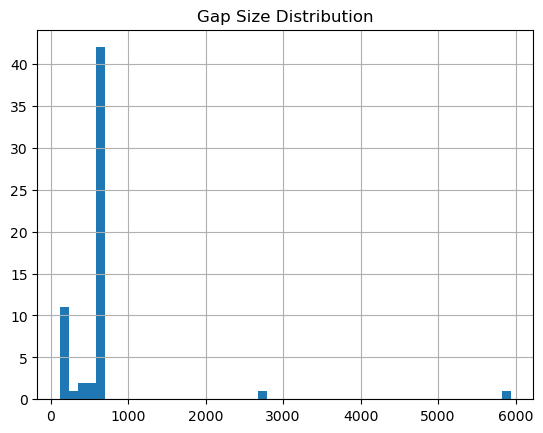

In [11]:
# Complete gap analysis
deltas = df_lstm.index.to_series().diff().dropna()
step = deltas.mode()[0]  # Base timestep
step_mins = int(step.total_seconds() / 60)

is_uniform_multiples = (deltas % step == pd.Timedelta(0)).all()
print(f"All steps divisible by {step_mins}min: {is_uniform_multiples}")

# 1. NUMBER OF GAPS (> base step)
gaps = deltas > step
num_gaps = gaps.sum()
print(f"Number of gaps: {num_gaps}")

# 2. GAP STATISTICS
gap_sizes_min = deltas[gaps].dt.total_seconds() / 60
print(f"Gap stats (min):")
print(f"  Mean: {gap_sizes_min.mean():.1f}")
print(f"  Median: {gap_sizes_min.median():.1f}")
print(f"  95th: {gap_sizes_min.quantile(0.95):.1f}")
print(f"  Max: {gap_sizes_min.max():.1f}")
print(f"Gap fraction: {num_gaps/len(deltas):.1%}")

# 3. GAP CATEGORIES
print("\nGap breakdown:")
print(f"  Short (2-{int(2*step_mins)}min): {(gap_sizes_min <= 2*step_mins).sum()}")
print(f"  Medium (2-24*step): {(gap_sizes_min > 2*step_mins) & (gap_sizes_min <= 24*step_mins)}.sum()")
print(f"  Large (>24*step): {(gap_sizes_min > 24*step_mins).sum()}")

# 4. VISUAL (optional)
gap_sizes_min.hist(bins=50)
plt.title('Gap Size Distribution')
plt.show()

#### Cyclically Encoding Time
We use cyclical encoding to allow the models to learn periodic features by representing times on a unit circle.

In [12]:
# Hour (0-23): Map to unit circle
df_lstm['hour_sin'] = np.sin(2 * np.pi * df_lstm.index.hour / 24)
df_lstm['hour_cos'] = np.cos(2 * np.pi * df_lstm.index.hour / 24)

# Day of year (1-365): Map to unit circle
df_lstm['doy_sin'] = np.sin(2 * np.pi * df_lstm.index.dayofyear / 365)
df_lstm['doy_cos'] = np.cos(2 * np.pi * df_lstm.index.dayofyear / 365)

#### Cyclically Encoding Solar Position 
We use cyclical encoding to inform the model on where the sun is physically located.

In [13]:
# Hong Kong central coordinates (covers most panels across territory)
hk_central = pvlib.location.Location(
    latitude=22.3, 
    longitude=114.2, 
    tz='Asia/Hong_Kong',  # or 'UTC+8'
    altitude=50  # conservative avg
)
# Compute solar position for your df timestamps
solar_position = hk_central.get_solarposition(df_lstm.index)

# Add to dataframe (drop elevation if you want, keep key angles)
df_lstm['zenith'] = solar_position['apparent_zenith']   # 0° overhead → 90° horizon → 180° night
df_lstm['azimuth'] = solar_position['azimuth']          # 0° N → 90° E → 180° S → 270° W

print("SZA sample:")
print(df_lstm[['zenith', 'azimuth']].head(10).round(1))
print(f"\nNight stats (zenith>95°): {len(df_lstm[df_lstm.zenith > 95])} / {len(df_lstm)} rows ({100*len(df_lstm[df_lstm.zenith > 95])/len(df_lstm):.1f}%)")

SZA sample:
                     zenith  azimuth
Time                                
2021-03-10 00:00:00    71.7    102.5
2021-03-10 01:00:00    58.4    110.0
2021-03-10 02:00:00    45.8    120.3
2021-03-10 03:00:00    34.9    136.2
2021-03-10 04:00:00    27.6    161.7
2021-03-10 05:00:00    27.1    194.6
2021-03-10 06:00:00    33.7    221.4
2021-03-10 07:00:00    44.4    238.3
2021-03-10 08:00:00    56.8    249.1
2021-03-10 10:00:00    83.7    263.1

Night stats (zenith>95°): 11005 / 24029 rows (45.8%)


In [14]:
# Zenith (0-180° → period=360 for full circle continuity at sunrise/sunset)
df_lstm['zenith_sin'] = np.sin(2 * np.pi * df_lstm['zenith'] / 360)
df_lstm['zenith_cos'] = np.cos(2 * np.pi * df_lstm['zenith'] / 360)

# Azimuth (0-360° → period=360 standard)
df_lstm['azimuth_sin'] = np.sin(2 * np.pi * df_lstm['azimuth'] / 360)
df_lstm['azimuth_cos'] = np.cos(2 * np.pi * df_lstm['azimuth'] / 360)

# Optional: z-score normalize (matches your physics features)
for col in ['zenith_sin', 'zenith_cos', 'azimuth_sin', 'azimuth_cos']:
    df_lstm[col] = (df_lstm[col] - df_lstm[col].mean()) / df_lstm[col].std()

# Drop raw angles (redundant)
df_lstm.drop(columns=['zenith', 'azimuth'], inplace=True)

In [15]:
df_lstm.head()

,irradiance,relative_humidity,temperature,SQ19,hour_sin,hour_cos,doy_sin,doy_cos,zenith_sin,zenith_cos,azimuth_sin,azimuth_cos
Time,,,,,,,,,,,,
2021-03-10 00:00:00,4.639122,76.729933,17.641750,0.0,0.000000,1.000000,0.927542,0.37372,0.897622,0.464828,1.131945,-0.457506
2021-03-10 01:00:00,4.673955,76.763667,17.574400,0.0,0.258819,0.965926,0.927542,0.37372,0.495135,0.794931,1.088807,-0.697555
2021-03-10 02:00:00,4.833763,79.332767,17.494717,0.0,0.500000,0.866025,0.927542,0.37372,-0.058858,1.066484,0.998933,-1.007897
2021-03-10 03:00:00,4.716148,76.912300,17.541183,0.0,0.707107,0.707107,0.927542,0.37372,-0.658457,1.260729,0.797921,-1.421458
2021-03-10 04:00:00,4.651888,73.599467,17.446050,0.0,0.866025,0.500000,0.927542,0.37372,-1.106859,1.364364,0.353464,-1.855578


#### Splitting Data
We perform a temporal train-validation-test split (70%-15%-15%) to preserve temporal ordering and avoid data leakage in time-series forecasting

In [16]:
train_size = int(len(df_lstm) * 0.7)
val_size = int(len(df_lstm) * 0.15)

train = df_lstm[:train_size]
val = df_lstm[train_size:train_size+val_size]
test = df_lstm[train_size+val_size:]

#### Finding the IMFs using VMD
---
Variational Mode Decomposition decomposes signals into K smooth frequency components (called Intrinsic Mode Functions / IMFs) and a residual. <br>
https://agupubs.onlinelibrary.wiley.com/doi/full/10.1029/2023SW003552

##### Imputing Power for Constant Time Gaps

In [17]:
def prepare_power_vmd(df_slice, power_col, step_mins, zenith_col='zenith_cos'):
    df_slice = df_slice.sort_index()

    if not df_slice.index.is_unique:
        raise ValueError("Duplicate timestamps found in df_slice.index")

    start_time = df_slice.index.min()
    end_time = df_slice.index.max()
    full_index = pd.date_range(start_time, end_time, freq=f"{step_mins}min")

    power_reindexed = df_slice[power_col].reindex(full_index)
    zenith_reindexed = df_slice[zenith_col].reindex(full_index)

    power_filled = (
        power_reindexed
        .interpolate(method='time', limit_area='inside')
        .ffill()
        .bfill()
    )

    zenith_filled = (
        zenith_reindexed
        .interpolate(method='time', limit_area='inside')
        .ffill()
        .bfill()
    )

    original_mask = full_index.isin(df_slice.index)
    inserted_mask = ~original_mask

    clamp_mask = inserted_mask & (zenith_filled.to_numpy() < 0)

    power_vmd = power_filled.to_numpy().copy()
    power_vmd[clamp_mask] = 0.0

    orig_indices = full_index.get_indexer(df_slice.index)
    if np.any(orig_indices < 0):
        missing = df_slice.index[orig_indices < 0]
        raise ValueError(f"Some original timestamps not found in full_index: {missing[:5]}")

    assert np.array_equal(full_index[orig_indices], df_slice.index)

    return power_vmd, original_mask, full_index



# Usage
train_power_imp, train_orig_idx, train_vmd_times = prepare_power_vmd(train, power_column, step_mins)
val_power_imp, val_orig_idx, val_vmd_times = prepare_power_vmd(val, power_column, step_mins)
test_power_imp, test_orig_idx, test_vmd_times = prepare_power_vmd(test, power_column, step_mins)

# #Log transform power for better IMFs
# train_power_log = np.log1p(train_power_imp)
# val_power_log = np.log1p(val_power_imp) 
# test_power_log = np.log1p(test_power_imp)

##### VMD Function & Genetic Algorithm to Optimise $K$ and $\alpha$
---
The Genetic Algorithm is an optimisation method used to search for an optimal set of parameters. The usage of this is inspired by the paper referenced below. It evolves a population of candidate solutions over generations, mimicking natural selection. <br>
https://agupubs.onlinelibrary.wiley.com/doi/full/10.1029/2023SW003552 <br> 

**1. Population Initialisation** <br>
Randomly sample `pop_size` candidates from $K\in [K_{min},K_{max}]$, $\alpha\in [\alpha_{min},\alpha_{max}]$: <br>
> $K_i \sim \text{Uniform}(K_{min},K_{max}), \: \alpha_i \sim \text{Uniform}(\alpha_{min},\alpha_{max})$

**2. Fitness Function (Envelope Entropy)**<br>
For each candidate pair $(K, \alpha)$, run VMD and then compute average IMF envelope entropy. This is defined as:
> $E_p = −\Sigma[\epsilon(i)\ln(\epsilon(i))]\: \: \text{where} \: \: \epsilon(i) = \frac{a(i)}{\Sigma a(i)}$ 

> $a(i) = |\mathcal{H}\{ \text{IMF}_k(i) \}  |$

> $ \text{fitness}(K, \alpha) = \text{mean}(Ep_k) \: \: \text{for} \: \: k=1 \: \: \text{to}\: \: K$

**3. Tournament Selection** <br>
Pick `tournament_size=3` random candidates, choose best (lowest fitness).<br>

**4. Crossover** <br>
Mix parents with `crossover_prob = 0.9`.
> $\alpha_\text{child1} = \lambda \alpha_\text{parent1} + (1-\lambda)\alpha_\text{parent2}$

> $K_\text{child1} = \text{round}(\frac{K_\text{parent1} + K_\text{parent2}}{2}) $

**5. Mutation**<br>
Randomly tweak $K$ or $\alpha$ with probability `mutation_prob = 0.1`.
>$K' \sim \text{Uniform}(K_\text{min}, K_\text{max})$

> $\alpha' = \alpha + \mathcal{N}(0, 0.1\times \alpha_\text{range})$

In [18]:
def vmd_power_exact(power_raw_imp, alpha, K, tol=1e-6):
    """VMD w/ guaranteed exact length match."""
    orig_len = len(power_raw_imp)
    u, _, _ = VMD(power_raw_imp, alpha, 0, K, False, 1, tol)
    
    # Pad/truncate to exact original length
    if u.shape[1] < orig_len:
        # Rare pad (unlikely)
        pad_width = orig_len - u.shape[1]
        u = np.pad(u, ((0,0),(0,pad_width)), mode='edge')
    elif u.shape[1] > orig_len:
        # Common truncate
        u = u[:, :orig_len]
    assert u.shape[1] == orig_len, f"VMD length mismatch: {u.shape[1]} != {orig_len}"
    return u

In [19]:
# =========================================================
# 1) Envelope entropy fitness (paper-style)
# =========================================================

def envelope_entropy_1d(x, eps=1e-12):
    """
    Envelope entropy for a single 1D signal.
    Ep = -sum(p_i * log(p_i)), where p_i is the normalized envelope.
    """
    x = np.asarray(x, dtype=float)
    analytic = hilbert(x)
    envelope = np.abs(analytic)

    s = envelope.sum()
    if not np.isfinite(s) or s <= eps:
        return np.inf

    p = envelope / (s + eps)
    p = np.clip(p, eps, None)
    return -np.sum(p * np.log(p))


def vmd_fitness_envelope_entropy(signal, alpha, K):
    """
    One scalar fitness for GA.
    We decompose the signal and average envelope entropy across IMFs.
    Lower is better.
    """
    K = int(round(K))
    K = max(2, min(10, K))
    alpha = float(alpha)
    alpha = max(1.0, min(5000.0, alpha))

    try:
        imfs = vmd_power_exact(signal, alpha=alpha, K=K)
        entropies = [envelope_entropy_1d(imfs[i]) for i in range(imfs.shape[0])]
        fit = float(np.mean(entropies))
        if not np.isfinite(fit):
            return np.inf
        return fit
    except Exception:
        return np.inf


# =========================================================
# 2) Optional diagnostics for the winning candidate
# =========================================================

def vmd_diagnostics(signal, alpha, K):
    imfs = vmd_power_exact(signal, alpha=alpha, K=K)
    recon = imfs.sum(axis=0)
    resid = signal - recon

    sse = np.sum((signal - recon) ** 2)
    sst = np.sum((signal - np.mean(signal)) ** 2)
    recon_r2 = 1.0 - sse / sst if sst > 0 else np.nan

    resid_rmse = float(np.sqrt(np.mean(resid ** 2)))
    resid_var_ratio = float(np.var(resid) / (np.var(signal) + 1e-12))

    return {
        "imfs": imfs,
        "recon": recon,
        "resid": resid,
        "recon_r2": recon_r2,
        "resid_rmse": resid_rmse,
        "resid_var_ratio": resid_var_ratio,
    }


# =========================================================
# 3) GA components
# =========================================================

def init_population(pop_size, K_bounds=(2, 10), alpha_bounds=(0, 5000), seed=42):
    rng = np.random.default_rng(seed)
    pop = []
    for _ in range(pop_size):
        K = rng.integers(K_bounds[0], K_bounds[1] + 1)
        alpha = rng.uniform(alpha_bounds[0], alpha_bounds[1])
        pop.append([float(K), float(alpha)])
    return np.array(pop, dtype=float)


def tournament_select(population, fitnesses, tournament_size=3, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    idx = rng.choice(len(population), size=tournament_size, replace=False)
    best_idx = idx[np.argmin(fitnesses[idx])]
    return population[best_idx].copy()


def crossover(parent1, parent2, crossover_prob=0.9, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    c1, c2 = parent1.copy(), parent2.copy()

    if rng.random() < crossover_prob:
        # Arithmetic crossover for alpha, swap-or-average for K
        lam = rng.random()
        c1[1] = lam * parent1[1] + (1 - lam) * parent2[1]
        c2[1] = (1 - lam) * parent1[1] + lam * parent2[1]

        if rng.random() < 0.5:
            c1[0], c2[0] = parent2[0], parent1[0]
        else:
            avgK = round((parent1[0] + parent2[0]) / 2.0)
            c1[0], c2[0] = avgK, avgK

    return c1, c2


def mutate(individual, mutation_prob=0.1, K_bounds=(2, 10), alpha_bounds=(0, 5000), rng=None):
    if rng is None:
        rng = np.random.default_rng()

    child = individual.copy()

    if rng.random() < mutation_prob:
        child[0] = rng.integers(K_bounds[0], K_bounds[1] + 1)

    if rng.random() < mutation_prob:
        alpha_span = alpha_bounds[1] - alpha_bounds[0]
        child[1] += rng.normal(0, 0.10 * alpha_span)

    child[0] = float(int(np.clip(round(child[0]), K_bounds[0], K_bounds[1])))
    child[1] = float(np.clip(child[1], alpha_bounds[0], alpha_bounds[1]))

    return child


# =========================================================
# 4) Main GA
# =========================================================

def ga_optimize_vmd(
    train_signal,
    pop_size=30,
    n_generations=50,
    crossover_prob=0.9,
    mutation_prob=0.1,
    K_bounds=(2, 10),
    alpha_bounds=(0, 5000),
    elite_size=2,
    tournament_size=3,
    seed=42,
    show_individuals=True,  # NEW: per-individual progress
    patience = 10
):
    rng = np.random.default_rng(seed)
    population = init_population(pop_size, K_bounds, alpha_bounds, seed)

    history = []
    best_solution = None
    best_fitness = np.inf
    stagnant_count = 0
    
    print(f"GA START: {pop_size} pop, {n_generations} gens, signal len={len(train_signal)}")
    print("-" * 60)

    for gen in range(n_generations):
        print(f"\n=== [Gen {gen+1:02d}/{n_generations}] ===")

        # Fitness evaluation with progress
        fitnesses = []
        for i, ind in enumerate(population):
            if show_individuals and i % 10 == 0:
                print(f"  Eval {i+1:2d}/{pop_size} K={int(round(ind[0]))} alpha={ind[1]:.0f}...", end=" ")
            
            fit = vmd_fitness_envelope_entropy(train_signal, ind[1], ind[0])
            fitnesses.append(fit)
            
            if show_individuals and i % 5 == 0:
                print(f"fit={fit:.4f}")

        fitnesses = np.array(fitnesses, dtype=float)
        
        # Sort and update best
        order = np.argsort(fitnesses)
        population = population[order]
        fitnesses = fitnesses[order]

        if fitnesses[0] < best_fitness:
            best_fitness = fitnesses[0]
            best_solution = population[0].copy()
            stagnant_count = 0
        else:
            stagnant_count += 1
            
        # EARLY STOP
        if stagnant_count >= patience:
            print(f"\nEARLY STOP: No improvement for {patience} gens")
            print(f"Final best: fit={best_fitness:.6f}")
            break
            
        history.append({
            "generation": gen + 1,
            "best_fitness": float(fitnesses[0]),
            "best_K": int(round(population[0][0])),
            "best_alpha": float(population[0][1]),
            "mean_fitness": float(np.mean(fitnesses[np.isfinite(fitnesses)]))
        })

        print(f"  [Gen {gen+1}] Best: fit={fitnesses[0]:.6f} K={int(round(population[0][0]))} alpha={population[0][1]:.1f}")
        print(f"  Mean fitness: {np.mean(fitnesses[np.isfinite(fitnesses)]):.6f} | Finite: {np.sum(np.isfinite(fitnesses))}/{pop_size}")
            
        # Evolution step (no print needed, it's fast)
        next_population = []
        for i in range(elite_size):
            next_population.append(population[i].copy())

        while len(next_population) < pop_size:
            p1 = tournament_select(population, fitnesses, tournament_size, rng)
            p2 = tournament_select(population, fitnesses, tournament_size, rng)
            c1, c2 = crossover(p1, p2, crossover_prob, rng)
            c1 = mutate(c1, mutation_prob, K_bounds, alpha_bounds, rng)
            c2 = mutate(c2, mutation_prob, K_bounds, alpha_bounds, rng)
            next_population.append(c1)
            if len(next_population) < pop_size:
                next_population.append(c2)

        population = np.array(next_population, dtype=float)

    print("\n" + "=" * 60)
    print("GA COMPLETE")
    print(f"Best: K={best_solution[0]:.1f} alpha={best_solution[1]:.1f} fitness={best_fitness:.6f}")

    return {
        "best_K": int(round(best_solution[0])),
        "best_alpha": float(best_solution[1]),
        "best_fitness": float(best_fitness),
        "history": pd.DataFrame(history)
    }

##### Running GA on Train data only

##### Performing Variational Mode Decomposition

In [20]:
best_alpha, best_K = 100.0 , 7

In [21]:
train_imfs_raw = vmd_power_exact(train_power_imp, best_alpha, best_K)
val_imfs_raw = vmd_power_exact(val_power_imp, best_alpha, best_K)
test_imfs_raw = vmd_power_exact(test_power_imp, best_alpha, best_K)

# Recon check
train_recon_raw = train_imfs_raw.sum(axis=0)
reconr2 = r2_score(train_power_imp, train_recon_raw)
print(f"Recon R²: {reconr2:.4f}")

Recon R²: 0.9998


In [22]:
# Append residuals as extra "IMF" at index -1
train_imfs_raw = np.vstack([train_imfs_raw, train_power_imp - train_imfs_raw.sum(axis=0)])
val_imfs_raw   = np.vstack([val_imfs_raw,   val_power_imp   - val_imfs_raw.sum(axis=0)])   
test_imfs_raw  = np.vstack([test_imfs_raw,   test_power_imp  - test_imfs_raw.sum(axis=0)])

print(f"train_imfs_raw shape: {train_imfs_raw.shape}")  # (5, 17185)
print(f"IMFs 0-{best_K-1}: components, IMF {best_K}: residual")

# Verify perfect reconstruction
train_recon_check = train_imfs_raw.sum(axis=0)
print(f"Recon R² with residual: {r2_score(train_power_imp, train_recon_check):.4f}")  # Should be ~1.0000

train_imfs_raw shape: (8, 17186)
IMFs 0-6: components, IMF 7: residual
Recon R² with residual: 1.0000


#### Aligning IMFs back with data cols

In [23]:
# **Slice using saved indices**
train_imfs_obs = train_imfs_raw[:, train_orig_idx]  # Magic!
val_imfs_obs = val_imfs_raw[:, val_orig_idx]
test_imfs_obs = test_imfs_raw[:, test_orig_idx]

print(f"IMFs final: train {train_imfs_obs.shape}")

IMFs final: train (8, 16820)


In [24]:
# Full exact check
assert np.array_equal(train_vmd_times[train_orig_idx], train.index)

print("Recovered originals exactly:",
      np.array_equal(train_vmd_times[train_orig_idx], train.index))

print("IMFs sliced:", train_imfs_obs.shape, "matches train:", len(train))

Recovered originals exactly: True
IMFs sliced: (8, 16820) matches train: 16820


#### Scaling Data
We normalize using separate scalers: one `MinMaxScaler` fitted on training weather features (then applied identically to val/test), and one `MinMaxScaler` per IMF for power outputs (fitted on training set, then applied identically to val/test). 

In [25]:
weather_features_engineered = weather_features + [#'hour_sin', 
                                                  #'hour_cos', 
                                                  #'doy_sin', 
                                                  #'doy_cos',
                                                  'zenith_sin',
                                                  'zenith_cos',
                                                  'azimuth_sin',
                                                  'azimuth_cos'
                                                 ]

# Normalize weather features (one scaler for all)
weather_scaler = MinMaxScaler()
train_weather_scaled = weather_scaler.fit_transform(train[weather_features_engineered])
val_weather_scaled = weather_scaler.transform(val[weather_features_engineered])
test_weather_scaled = weather_scaler.transform(test[weather_features_engineered])

# Normalize power output for LSTM
power_scaler = MinMaxScaler()
train_power_scaled = power_scaler.fit_transform(train[power_column].values.reshape(-1, 1)).flatten()
val_power_scaled = power_scaler.transform(val[power_column].values.reshape(-1, 1)).flatten()
test_power_scaled = power_scaler.transform(test[power_column].values.reshape(-1, 1)).flatten()

# IMF scaling (per K) for VMD LSTMs
imf_scalers = []
train_imf_scaled = np.zeros((best_K+1, len(train)))
val_imf_scaled = np.zeros((best_K+1, len(val)))
test_imf_scaled = np.zeros((best_K+1, len(test)))

for k in range(best_K+1):
    print(f"Scaling IMF {k+1}/{best_K+1}...")
    scaler_k = MinMaxScaler()
    
    # Fit on train IMF_k, transform all
    train_k_scaled = scaler_k.fit_transform(train_imfs_obs[k].reshape(-1, 1)).flatten()
    val_k_scaled = scaler_k.transform(val_imfs_obs[k].reshape(-1, 1)).flatten()
    test_k_scaled = scaler_k.transform(test_imfs_obs[k].reshape(-1, 1)).flatten()
    
    train_imf_scaled[k] = train_k_scaled
    val_imf_scaled[k] = val_k_scaled
    test_imf_scaled[k] = test_k_scaled
    imf_scalers.append(scaler_k)

print("IMF scaling complete!")

Scaling IMF 1/8...
Scaling IMF 2/8...
Scaling IMF 3/8...
Scaling IMF 4/8...
Scaling IMF 5/8...
Scaling IMF 6/8...
Scaling IMF 7/8...
Scaling IMF 8/8...
IMF scaling complete!


#### Data Sequencing 
Finally, we create sequences with a 24-hour lookback window.

In [26]:
def create_sequences(weather_data, y_data, timestamps, lookback, horizon, step_mins=60):
    X, y = [], []
    expected_gap = pd.Timedelta(minutes=step_mins)

    for i in range(len(weather_data) - lookback - horizon + 1):  # +1 to avoid off-by-one
        # Check full window: lookback + horizon steps must all be contiguous
        window_timestamps = timestamps[i : i + lookback + horizon]
        diffs = np.diff(window_timestamps)

        if not all(d == expected_gap for d in diffs):
            continue

        weather_seq = weather_data[i : i + lookback]
        y_slice     = y_data[i : i + lookback]
        y_seq       = y_slice.reshape(-1, 1) if y_slice.ndim == 1 else y_slice[:, [0]]

        X.append(np.concatenate([weather_seq, y_seq], axis=-1))
        y.append(y_data[i + lookback : i + lookback + horizon])   # shape: (horizon,)

    return np.array(X), np.array(y)  # X: (N, lookback, features), y: (N, horizon)



# Lookback params
lookback_steps = 48
horizon = 24

#Create sequences for standard LSTM 
print("Creating standard LSTM sequence...")
standard_X_train, standard_y_train = create_sequences(train_weather_scaled, train_power_scaled, train.index.to_numpy(), lookback_steps,horizon)
standard_X_val, standard_y_val = create_sequences(val_weather_scaled, val_power_scaled, val.index.to_numpy(), lookback_steps,horizon)
standard_X_test, standard_y_test = create_sequences(test_weather_scaled, test_power_scaled, test.index.to_numpy(),  lookback_steps,horizon)
print(f"Sequences ready for standard LSTM. Train dimensions are {standard_X_train.shape, standard_y_train.shape}")
# Create sequences for ALL K VMD-LSTM models
imf_X_train_list = []
imf_y_train_list = []
imf_X_val_list = []
imf_y_val_list = []
imf_X_test_list = []
imf_y_test_list = []

print("Creating VMD-LSTM Ensemble sequences...")
for k in range(best_K+1):
    print(f"IMF {k+1}/{best_K+1}...")
    
    # Train
    X_train_k, y_train_k = create_sequences(train_weather_scaled, train_imf_scaled[k], train.index.to_numpy(), lookback_steps,horizon)
    imf_X_train_list.append(X_train_k)
    imf_y_train_list.append(y_train_k)
    
    # Val  
    X_val_k, y_val_k = create_sequences(val_weather_scaled, val_imf_scaled[k], val.index.to_numpy(), lookback_steps,horizon)
    imf_X_val_list.append(X_val_k)
    imf_y_val_list.append(y_val_k)
    
    # Test
    X_test_k, y_test_k = create_sequences(test_weather_scaled, test_imf_scaled[k], test.index.to_numpy(), lookback_steps,horizon)
    imf_X_test_list.append(X_test_k)
    imf_y_test_list.append(y_test_k)

print(f"Sequences ready: X_train shapes {[(x.shape, y.shape) for x,y in zip(imf_X_train_list, imf_y_train_list)]}")


Creating standard LSTM sequence...
Sequences ready for standard LSTM. Train dimensions are ((15011, 48, 8), (15011, 24))
Creating VMD-LSTM Ensemble sequences...
IMF 1/8...
IMF 2/8...
IMF 3/8...
IMF 4/8...
IMF 5/8...
IMF 6/8...
IMF 7/8...
IMF 8/8...
Sequences ready: X_train shapes [((15011, 48, 8), (15011, 24)), ((15011, 48, 8), (15011, 24)), ((15011, 48, 8), (15011, 24)), ((15011, 48, 8), (15011, 24)), ((15011, 48, 8), (15011, 24)), ((15011, 48, 8), (15011, 24)), ((15011, 48, 8), (15011, 24)), ((15011, 48, 8), (15011, 24))]


In [27]:
# Check first IMF sequences
print(f"IMF 0 - X_train: {imf_X_train_list[0].shape}")  # (16806, 12, 15)
print(f"IMF 0 - y_train: {imf_y_train_list[0].shape}") # (16806,)
print(f"IMF 0 - X_val: {imf_X_val_list[0].shape}")

# Verify all identical X shapes
x_train_shapes = [x.shape for x in imf_X_train_list]
print(f"All X_train shapes identical: {len(set(x_train_shapes)) == 1}")

# Sample sizes
print(f"n_train_samples: {imf_X_train_list[0].shape[0]}")
print(f"lookback steps: {imf_X_train_list[0].shape[1]}")
print(f"n_weather_features: {imf_X_train_list[0].shape[2]}")


IMF 0 - X_train: (15011, 48, 8)
IMF 0 - y_train: (15011, 24)
IMF 0 - X_val: (3074, 48, 8)
All X_train shapes identical: True
n_train_samples: 15011
lookback steps: 48
n_weather_features: 8


#### Converting Data into Tensors + DataLoaders
Once this is done we also check for bad data (inf, NaN).

In [28]:
batch_size = 32

#Standard LSTM
standard_train_dataset = torch.utils.data.TensorDataset(
    torch.FloatTensor(standard_X_train),
    torch.FloatTensor(standard_y_train)
)

standard_val_dataset = torch.utils.data.TensorDataset(
    torch.FloatTensor(standard_X_val),
    torch.FloatTensor(standard_y_val)
)

standard_test_dataset = torch.utils.data.TensorDataset(
    torch.FloatTensor(standard_X_test),
    torch.FloatTensor(standard_y_test)
)
standard_train_loader = DataLoader(standard_train_dataset, batch_size=batch_size, shuffle=True)
standard_val_loader = DataLoader(standard_val_dataset, batch_size=batch_size, shuffle=False)
standard_test_loader = DataLoader(standard_test_dataset, batch_size=batch_size, shuffle=False)

# DataLoaders for each IMF in VMD-LSTM Ensemble
imf_train_loaders = []
imf_val_loaders = []
imf_test_loaders = []
for k in range(best_K+1):
    # Train loader
    imf_train_dataset = torch.utils.data.TensorDataset(
        torch.FloatTensor(imf_X_train_list[k]), 
        torch.FloatTensor(imf_y_train_list[k]))
    imf_train_loaders.append(DataLoader(imf_train_dataset, batch_size=batch_size, shuffle=True))
    
    # Val loader  
    imf_val_dataset = torch.utils.data.TensorDataset(
        torch.FloatTensor(imf_X_val_list[k]), 
        torch.FloatTensor(imf_y_val_list[k]))
    imf_val_loaders.append(DataLoader(imf_val_dataset, batch_size=batch_size, shuffle=False))

    # Test loader  
    imf_test_dataset = torch.utils.data.TensorDataset(
        torch.FloatTensor(imf_X_test_list[k]), 
        torch.FloatTensor(imf_y_test_list[k]))
    imf_test_loaders.append(DataLoader(imf_test_dataset, batch_size=batch_size, shuffle=False))

In [29]:
# === IMF ENSEMBLE DATA QUALITY CHECKS ===
print("=== 1. IMF Scaled Data (Before Sequences) ===")
for k in range(min(3, best_K+1)):  # First 3 IMFs
    print(f"IMF {k}: train min/max/NaN/inf: "
          f"{train_imf_scaled[k].min():.2f}/{train_imf_scaled[k].max():.2f}/"
          f"{np.isnan(train_imf_scaled[k]).sum()}/{np.isinf(train_imf_scaled[k]).sum()}")

print(f"\nWeather train NaN/inf: {np.isnan(train_weather_scaled).sum()}/{np.isinf(train_weather_scaled).sum()}")

print("\n=== 2. Sequence Quality (First 3 IMFs) ===")
for k in range(min(3, best_K+1)):
    print(f"IMF {k} - X_train NaN/inf/shape: "
          f"{np.isnan(imf_X_train_list[k]).sum()}/{np.isinf(imf_X_train_list[k]).sum()}/{imf_X_train_list[k].shape}")
    print(f"          y_train NaN/inf/shape: "
          f"{np.isnan(imf_y_train_list[k]).sum()}/{np.isinf(imf_y_train_list[k]).sum()}/{imf_y_train_list[k].shape}")
    print(f"          X range: {imf_X_train_list[k].min():.2f}/{imf_X_train_list[k].max():.2f}")
    print(f"          y range: {imf_y_train_list[k].min():.2f}/{imf_y_train_list[k].max():.2f}\n")

print("=== 3. DataLoader Sanity (First IMF) ===")
batch_x, batch_y = next(iter(imf_train_loaders[0]))
print(f"Batch shape: X{batch_x.shape} y{batch_y.shape}")
print(f"Batch NaN/inf: X{torch.isnan(batch_x).sum().item()} y{torch.isnan(batch_y).sum().item()}")
print(f"Batch range: X{batch_x.min().item():.2f}/{batch_x.max().item():.2f} y{batch_y.min().item():.2f}/{batch_y.max().item():.2f}")

print("\n=== 4. Ensemble Consistency ===")
x_shapes = [x.shape for x in imf_X_train_list]
print(f"All X_train shapes identical: {len(set(x_shapes)) == 1}")
print(f"All y_train lengths identical: {all(len(y) == len(imf_y_train_list[0]) for y in imf_y_train_list)}")

print("\n✓ ALL CLEAN - READY TO TRAIN!")

=== 1. IMF Scaled Data (Before Sequences) ===
IMF 0: train min/max/NaN/inf: 0.00/1.00/0/0
IMF 1: train min/max/NaN/inf: 0.00/1.00/0/0
IMF 2: train min/max/NaN/inf: 0.00/1.00/0/0

Weather train NaN/inf: 0/0

=== 2. Sequence Quality (First 3 IMFs) ===
IMF 0 - X_train NaN/inf/shape: 0/0/(15011, 48, 8)
          y_train NaN/inf/shape: 0/0/(15011, 24)
          X range: 0.00/1.00
          y range: 0.01/1.00

IMF 1 - X_train NaN/inf/shape: 0/0/(15011, 48, 8)
          y_train NaN/inf/shape: 0/0/(15011, 24)
          X range: 0.00/1.00
          y range: 0.00/1.00

IMF 2 - X_train NaN/inf/shape: 0/0/(15011, 48, 8)
          y_train NaN/inf/shape: 0/0/(15011, 24)
          X range: 0.00/1.00
          y range: 0.00/1.00

=== 3. DataLoader Sanity (First IMF) ===
Batch shape: Xtorch.Size([32, 48, 8]) ytorch.Size([32, 24])
Batch NaN/inf: X0 y0
Batch range: X0.00/1.00 y0.02/0.97

=== 4. Ensemble Consistency ===
All X_train shapes identical: True
All y_train lengths identical: True

✓ ALL CLEAN - 

## Train LSTM

#### Defining Solar LSTM

In [30]:
class SolarLSTM(nn.Module):
    """LSTM model for solar power forecasting"""
    
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.2):
        """
        Args:
            input_size: Number of input features
            hidden_size: Number of hidden units in LSTM
            num_layers: Number of LSTM layers
            output_size: Number of output features (1 for single value prediction)
            dropout: Dropout probability
        """
        super(SolarLSTM, self).__init__()
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # LSTM layer
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True, # match DataLoader output
            dropout=dropout if num_layers > 1 else 0
        )
        
        # Fully connected output layer
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_size, output_size)
        )

        
    def forward(self, x):
        """
        Forward pass
        
        Args:
            x: Input tensor of shape (batch_size, lookback, input_size)
            
        Returns:
            output: Predictions of shape (batch_size, output_size)
        """
        # Initialize hidden and cell states
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        # Forward propagate LSTM
        # out shape: (batch_size, lookback, hidden_size)
        out, _ = self.lstm(x, (h0, c0))
        
        # Get output from last time step
        out = out[:, -1, :]
        
        # Pass through fully connected layer
        out = self.fc(out)
        
        return out
######################################################################################
class LSTMTrainer:
    """Training wrapper for LSTM model"""
    
    def __init__(self, model, learning_rate=0.001):
        self.model = model
        self.criterion = nn.MSELoss()
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
        print(f"CUDA available: {torch.cuda.is_available()}")
        print(f"Device selected: {self.device}")
        
        self.model.to(self.device)
        print(f"Model device after .to(): {next(self.model.parameters()).device}")
        
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=learning_rate)
        self.scheduler = ReduceLROnPlateau(self.optimizer, mode='min', factor=0.5, patience=3,min_lr = 1e-4)
        
    def train_epoch(self, train_loader):
        """Train for one epoch"""
        self.model.train()
        total_loss = 0
        
        for batch_x, batch_y in train_loader:
            batch_x = batch_x.to(self.device)
            batch_y = batch_y.to(self.device)

            # # IRRADIANCE at t-1 = LAST timestep, FEATURE 0
            # irr_t_minus_1 = batch_x[:, -1, 0]  # shape: [batch_size]
            
            # Forward pass
            outputs = self.model(batch_x)
            # WEIGHT: High recent irradiance → care more about this prediction
            # weights = torch.clamp(irr_t_minus_1 / irr_t_minus_1.mean(), 0.2, 5.0)
            # loss = torch.mean(weights * self.criterion(outputs, batch_y))
            loss = self.criterion(outputs, batch_y)
            
            # Backward pass and optimization
            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()
            
            total_loss += loss.item()
        
        return total_loss / len(train_loader)
    
    def validate(self, val_loader):
        """Validate model"""
        self.model.eval()
        total_loss = 0
        
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x = batch_x.to(self.device)
                batch_y = batch_y.to(self.device)
                
                outputs = self.model(batch_x)
                loss = self.criterion(outputs, batch_y)
                total_loss += loss.item()
        
        return total_loss / len(val_loader)
    
    def fit(self, train_loader, val_loader, epochs=100, patience=15):
        """
        Train model with early stopping
        
        Args:
            train_loader: Training data loader
            val_loader: Validation data loader
            epochs: Maximum number of epochs
            patience: Early stopping patience
        """
        best_val_loss = float('inf')
        patience_counter = 0
        history = {'train_loss': [], 'val_loss': []}

        print(f"Starting training...")
        print(f"Device: {self.device}")
        print(f"Model parameters: {sum(p.numel() for p in self.model.parameters()):,}")
        print(f"Training samples: {len(train_loader.dataset)}")
        print(f"Validation samples: {len(val_loader.dataset)}")
        print("-" * 60)
        
        for epoch in range(epochs):
            train_loss = self.train_epoch(train_loader)
            val_loss = self.validate(val_loader)
        
            old_lr = self.optimizer.param_groups[0]['lr']
            self.scheduler.step(val_loss)
            new_lr = self.optimizer.param_groups[0]['lr']
        
            if new_lr != old_lr:
                print(f"LR reduced: {old_lr:.6e} -> {new_lr:.6e}")
            print(f"Epoch {epoch+1}, Train: {train_loss:.6f}, Val: {val_loss:.6f}")

            # ---- save to history ----
            history['train_loss'].append(train_loss)
            history['val_loss'].append(val_loss)

            # Early stopping
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                # Save best model
                torch.save(self.model.state_dict(), 'best_lstm_model.pth')
            else:
                patience_counter += 1
                
            if patience_counter >= patience:
                print(f'Early stopping at epoch {epoch+1}')
                break
        
        # Load best model
        self.model.load_state_dict(torch.load('best_lstm_model.pth'))
        return history

#### Standard LSTM Training Loop

In [31]:
standard_input_size = standard_X_train.shape[-1]
standard_model = SolarLSTM(
    input_size=standard_input_size,
    hidden_size=64,
    num_layers=2,
    output_size=horizon,
    dropout=0.2
)

#Train
standard_trainer = LSTMTrainer(standard_model, learning_rate=0.001)
standard_history = standard_trainer.fit(standard_train_loader, standard_val_loader, epochs=200, patience=15)

CUDA available: False
Device selected: cpu
Model device after .to(): cpu
Starting training...
Device: cpu
Model parameters: 57,944
Training samples: 15011
Validation samples: 3074
------------------------------------------------------------
Epoch 1, Train: 0.016967, Val: 0.012503
Epoch 2, Train: 0.011159, Val: 0.012108
Epoch 3, Train: 0.010693, Val: 0.012056
Epoch 4, Train: 0.010409, Val: 0.012117
Epoch 5, Train: 0.010355, Val: 0.011215
Epoch 6, Train: 0.010179, Val: 0.010896
Epoch 7, Train: 0.010096, Val: 0.011741
Epoch 8, Train: 0.009974, Val: 0.011969
Epoch 9, Train: 0.009812, Val: 0.011897
LR reduced: 1.000000e-03 -> 5.000000e-04
Epoch 10, Train: 0.009782, Val: 0.011244
Epoch 11, Train: 0.009486, Val: 0.011078
Epoch 12, Train: 0.009417, Val: 0.011264
Epoch 13, Train: 0.009405, Val: 0.011357
LR reduced: 5.000000e-04 -> 2.500000e-04
Epoch 14, Train: 0.009315, Val: 0.011382
Epoch 15, Train: 0.009122, Val: 0.011207
Epoch 16, Train: 0.009086, Val: 0.011222
Epoch 17, Train: 0.009036, Val

#### VMD-LSTM Ensemble Training Loop

In [32]:
# === VMD-LSTM ENSEMBLE TRAINING ===
models = []
histories = []

for k in range(best_K+1):
    print(f'\n=== Training IMF {k+1}/{best_K+1} ===')
    print(f"Data shape: X {imf_X_train_list[k].shape}, y {imf_y_train_list[k].shape}")
    
    # Your exact model
    input_size = imf_X_train_list[k].shape[-1]  #weather features
    model_k = SolarLSTM(
        input_size=input_size,
        hidden_size = 64 if k <=2 else 32,
        num_layers = 2 if k <= 2 else 1,
        output_size=horizon,
        dropout=0.2
    )
    
    # Your exact trainer
    trainer_k = LSTMTrainer(model_k, learning_rate=0.001)
    
    # Your exact fit
    history_k = trainer_k.fit(
        imf_train_loaders[k], 
        imf_val_loaders[k], 
        epochs=300 if k<=2 else 250, 
        patience=15
    )
    
    models.append(model_k)
    histories.append(history_k)
    
    # Best val loss
    print(f"IMF {k+1} best val MSE: {min(history_k['val_loss']):.6f}")
    
for k in range(best_K+1):
    best_mse = min(histories[k]['val_loss'])
    print(f"IMF {k+1:2d}: {best_mse:8.6f}")
print("\n🎉 VMD-LSTM ENSEMBLE FULLY TRAINED!")
torch.save({'models': models, 'imf_scalers': imf_scalers}, 'vmd_lstm_ensemble.pth')


=== Training IMF 1/8 ===
Data shape: X (15011, 48, 8), y (15011, 24)
CUDA available: False
Device selected: cpu
Model device after .to(): cpu
Starting training...
Device: cpu
Model parameters: 57,944
Training samples: 15011
Validation samples: 3074
------------------------------------------------------------
Epoch 1, Train: 0.030570, Val: 0.012567
Epoch 2, Train: 0.011431, Val: 0.010273
Epoch 3, Train: 0.009517, Val: 0.009971
Epoch 4, Train: 0.008175, Val: 0.008849
Epoch 5, Train: 0.007490, Val: 0.008216
Epoch 6, Train: 0.006792, Val: 0.007333
Epoch 7, Train: 0.006353, Val: 0.007007
Epoch 8, Train: 0.006094, Val: 0.006818
Epoch 9, Train: 0.005804, Val: 0.006765
Epoch 10, Train: 0.005612, Val: 0.006929
Epoch 11, Train: 0.005425, Val: 0.006784
Epoch 12, Train: 0.005247, Val: 0.007000
Epoch 13, Train: 0.005088, Val: 0.006679
Epoch 14, Train: 0.005060, Val: 0.007649
Epoch 15, Train: 0.004858, Val: 0.006591
Epoch 16, Train: 0.004818, Val: 0.006737
Epoch 17, Train: 0.004695, Val: 0.006427
E

## Test LSTMs

#### Standard LSTM Test

In [33]:
# Test loss
standard_test_loss = standard_trainer.validate(standard_test_loader)
print(f"Test Loss (MSE): {standard_test_loss:.6f}")

# Collect predictions
standard_model.eval()
predictions, actuals = [], []

with torch.no_grad():
    for batch_x, batch_y in standard_test_loader:
        batch_x = batch_x.to(standard_trainer.device)
        predictions.append(standard_model(batch_x).cpu().numpy())
        actuals.append(batch_y.cpu().numpy())

predictions = np.concatenate(predictions, axis=0)  # (N, 6)
actuals     = np.concatenate(actuals,     axis=0)  # (N, 6)

print(f"Predictions shape: {predictions.shape}")
print(f"Actuals shape:     {actuals.shape}")

# Denormalize — inverse_transform expects (N, 1), so do it per horizon
predictions_denorm = np.stack([
    power_scaler.inverse_transform(predictions[:, h].reshape(-1, 1)).flatten()
    for h in range(horizon)
], axis=1)  # (N, 6)

actuals_denorm = np.stack([
    power_scaler.inverse_transform(actuals[:, h].reshape(-1, 1)).flatten()
    for h in range(horizon)
], axis=1)  # (N, 6)

# Per-step metrics
print(f"\n{'Horizon':<10} {'RMSE':<12} {'MAE':<12} {'R²':<10}")
print("-" * 44)
standard_r2_list=[]
for h in range(horizon):
    p, a  = predictions_denorm[:, h], actuals_denorm[:, h]
    rmse  = np.sqrt(mean_squared_error(a, p))
    mae   = mean_absolute_error(a, p)
    r2    = r2_score(a, p)
    standard_r2_list.append(r2)
    print(f"t+{h+1:<8} {rmse:<12.4f} {mae:<12.4f} {r2:<10.4f}")

# Aggregate metrics (flattened over all horizons)
print("-" * 44)
p_flat, a_flat = predictions_denorm.flatten(), actuals_denorm.flatten()
print(f"{'Overall':<10} {np.sqrt(mean_squared_error(a_flat, p_flat)):<12.4f} "
      f"{mean_absolute_error(a_flat, p_flat):<12.4f} {r2_score(a_flat, p_flat):<10.4f}")

Test Loss (MSE): 0.008505
Predictions shape: (3058, 24)
Actuals shape:     (3058, 24)

Horizon    RMSE         MAE          R²        
--------------------------------------------
t+1        905.9680     527.7519     0.9721    
t+2        1622.7533    818.6268     0.9105    
t+3        2043.8050    1041.0569    0.8583    
t+4        2279.0065    1182.4315    0.8244    
t+5        2438.7426    1341.9967    0.7997    
t+6        2527.3286    1403.5206    0.7857    
t+7        2597.5444    1426.5559    0.7743    
t+8        2606.0302    1418.8130    0.7732    
t+9        2586.8489    1422.7794    0.7764    
t+10       2575.6517    1415.4679    0.7783    
t+11       2553.5236    1405.3583    0.7820    
t+12       2545.0314    1402.1146    0.7835    
t+13       2535.0790    1386.1880    0.7852    
t+14       2527.7591    1353.6146    0.7864    
t+15       2519.3085    1332.0593    0.7879    
t+16       2512.8187    1337.5190    0.7891    
t+17       2511.3595    1342.9392    0.7892    
t+18

#### VMD-LSTM Ensemble Test

In [34]:
device = next(models[0].parameters()).device

# Collect scaled predictions — shape (N, horizon) per IMF
imf_test_preds_scaled = []
for k in range(best_K + 1):
    models[k].eval()
    preds_k = []
    with torch.no_grad():
        for batch_x, _ in imf_test_loaders[k]:
            batch_x = batch_x.to(device)
            batch_pred = models[k](batch_x).cpu().numpy()   # (batch, horizon) — no squeeze
            preds_k.append(batch_pred)
    imf_test_preds_scaled.append(np.concatenate(preds_k, axis=0))  # (N, horizon)

# Denorm each IMF per horizon column, then stack back to (N, horizon)
def denorm_per_horizon(arr_2d, scaler):
    return np.stack([
        scaler.inverse_transform(arr_2d[:, h].reshape(-1, 1)).flatten()
        for h in range(horizon)
    ], axis=1)  # (N, horizon)

imf_test_preds_raw   = [denorm_per_horizon(imf_test_preds_scaled[k],          imf_scalers[k]) for k in range(best_K + 1)]
imf_test_actuals_raw = [denorm_per_horizon(imf_y_test_list[k],                 imf_scalers[k]) for k in range(best_K + 1)]

# Sum across IMFs — still (N, horizon)
total_power_pred_raw    = np.sum(imf_test_preds_raw,    axis=0)  # (N, horizon)
total_power_actuals_raw = np.sum(imf_test_actuals_raw,  axis=0)  # (N, horizon)

assert total_power_pred_raw.shape == total_power_actuals_raw.shape

# Per-step + aggregate metrics
print("\n" + "="*60)
print("VMD-LSTM ENSEMBLE")
print("="*60)
print(f"{'Horizon':<10} {'RMSE':<12} {'MAE':<12} {'R²':<10}")
print("-" * 44)
VMD_r2_list=[]
for h in range(horizon):
    p, a = total_power_pred_raw[:, h], total_power_actuals_raw[:, h]
    rmse = np.sqrt(mean_squared_error(a, p))
    mae  = mean_absolute_error(a, p)
    r2   = r2_score(a, p)
    VMD_r2_list.append(r2)
    print(f"t+{h+1:<8} {rmse:<12.1f} {mae:<12.1f} {r2:<10.4f}")
    
print("-" * 44)
p_flat = total_power_pred_raw.flatten()
a_flat = total_power_actuals_raw.flatten()
print(f"{'Overall':<10} {np.sqrt(mean_squared_error(a_flat, p_flat)):<12.1f} "
      f"{mean_absolute_error(a_flat, p_flat):<12.1f} {r2_score(a_flat, p_flat):<10.4f}")
print("="*60)


VMD-LSTM ENSEMBLE
Horizon    RMSE         MAE          R²        
--------------------------------------------
t+1        319.1        237.9        0.9965    
t+2        341.4        248.2        0.9960    
t+3        388.5        278.7        0.9949    
t+4        431.0        305.2        0.9937    
t+5        488.5        354.4        0.9920    
t+6        536.8        384.7        0.9903    
t+7        607.9        422.2        0.9876    
t+8        694.8        467.9        0.9839    
t+9        806.3        523.0        0.9783    
t+10       886.1        570.6        0.9738    
t+11       920.4        577.7        0.9717    
t+12       968.9        602.7        0.9686    
t+13       1037.8       632.9        0.9640    
t+14       1071.5       651.2        0.9616    
t+15       1102.9       674.2        0.9593    
t+16       1163.5       704.8        0.9548    
t+17       1239.7       757.0        0.9486    
t+18       1294.5       791.8        0.9438    
t+19       1363.3       

## Model Comparisons

Text(0, 0.5, '$R^2$')

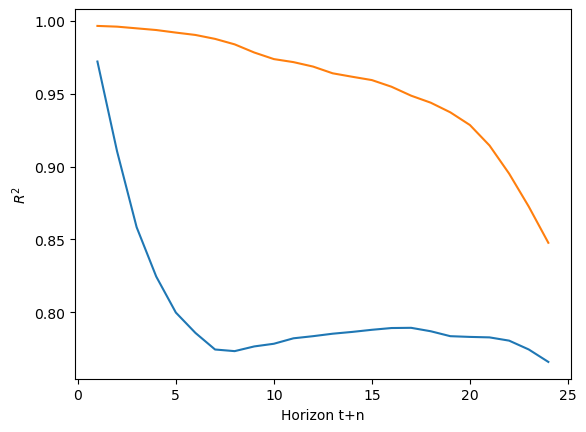

In [35]:
times = [t+1 for t in range(len(VMD_r2_list))]
plt.plot(times, standard_r2_list)
plt.plot(times, VMD_r2_list)
plt.xlabel("Horizon t+n")
plt.ylabel("$R^2$")

In [ ]:
# Naive baseline: predict the power from 24 hours ago (same time yesterday)
naive_predictions = actuals[:-2*lookback_steps]  # Shift actuals back 24 hours
naive_actuals = actuals[2*lookback_steps:]       # Match the remaining actuals

naive_rmse = np.sqrt(mean_squared_error(naive_actuals, naive_predictions))
naive_r2 = r2_score(naive_actuals, naive_predictions)

print(f"Naive Baseline (guesses using yesterdays value):")
print(f"  RMSE: {naive_rmse:.4f}")
print(f"  R²: {naive_r2:.4f}")

print(f"LSTM Model:")
print(f"  RMSE: {lstm_rmse:.4f}")
print(f"  R²: {lstm_r2:.4f}")

print(f"VMD LSTM Ensemble:")
print(f"  RMSE: {VMDlstm_rmse:.4f}")
print(f"  R²: {VMDlstm_r2:.4f}")

print(f"\nImprovement from VMD LSTM Ensemble:")
print(f"  RMSE reduction: {((naive_rmse - VMDlstm_rmse) / naive_rmse * 100):.1f}%")
print(f"  R² improvement: {(VMDlstm_r2 - naive_r2):.4f}")

# Stage 2: Generalised LSTM using Weather, Power, and Static Data.

## Loading Metadata

#### Reading metadata file

In [36]:
df_metadata = load_metadata('PV_generation_system_metadata.ttl') #filename

✓ Extracted metadata for 60 stations

Columns: ['station_id', 'latitude', 'longitude', 'location', 'altitude_m', 'capacity_kw', 'azimuth', 'tilt_angle', 'connection_date', 'contractor']

Capacity range: 3.7 - 249.5 kW
Total capacity: 2230.81 kW

Missing values:
station_id         0
latitude           0
longitude          0
location           6
altitude_m         0
capacity_kw        0
azimuth            0
tilt_angle         0
connection_date    0
contractor         0
dtype: int64


#### Parsing azimuth column
This converts the azimuth string into a float. All dual entries are averaged, and all "Mixed" entries are recorded as the median of the dataset.

In [37]:
def parse_angle(angle):
    """Parse angle str to num: ranges → mean, Mixed → NaN, pure num → float."""
    if pd.isna(angle):
        return np.nan
    s = str(angle).strip().replace('deg', '')
    if s == 'Mixed':
        return np.nan
    if '/' in s:
        vals = [float(x.strip()) for x in s.split('/')]
        return np.mean(vals)
    return float(s)

# Parse
df_metadata['azimuth_num'] = df_metadata['azimuth'].apply(parse_angle)
df_metadata['tilt_num'] = df_metadata['tilt_angle'].apply(parse_angle)

# After parsing...
az_med = df_metadata['azimuth_num'].median()
tilt_med = df_metadata['tilt_num'].median()
print(f'Medians used: azimuth={az_med}, tilt={tilt_med}')

# Fixed: no chained inplace
df_metadata['azimuth_num'] = df_metadata['azimuth_num'].fillna(az_med)
df_metadata['tilt_num'] = df_metadata['tilt_num'].fillna(tilt_med)

# Rest unchanged
df_metadata['azimuth_sin'] = np.sin(2 * np.pi * df_metadata['azimuth_num'] / 360)
df_metadata['azimuth_cos'] = np.cos(2 * np.pi * df_metadata['azimuth_num'] / 360)

Medians used: azimuth=0.0, tilt=0.0


#### Mapping Power stations between dataframes

In [38]:
# Exact mapping based on your power_features vs metadata station_id
station_mapping = {
    'CYT (Station 1)': 'CYT__Station_1_',
    'CYT (Station 2)': 'CYT__Station_2_',
    'Indoor Sports Centre': 'Indoor_Sport_Center',
    'LSK North': 'LSK_North',
    'LSK South': 'LSK_South',
    'S H Ho Sports Hall': 'S_H_Ho_Sports_Hall',
    'Shaw Auditorium': 'Shaw_Auditorium',
    'Tower A': 'Tower_A',
    'Wong Check She Research Centre': 'Wong_Check_She_Research_Centre',
    'Zone A1': 'Zone_A1',
    'Zone A2': 'Zone_A2',
    'Zone A4': 'Zone_A4',
    'Zone A5': 'Zone_A5',
    'Zone A6': 'Zone_A6',
    'Zone A7': 'Zone_A7',
    'Zone D': 'Zone_D',
    'Zone J1': 'Zone_J1',
    'Zone J2': 'Zone_J2',
    'Zone L1 (Station 1)': 'Zone_L1__Station_1_',
    'Zone L1(Station 2)': 'Zone_L1__Station_2_',
    'Zone L2': 'Zone_L2',
    'SQ Block P': 'SQ_Block_P',
    'SQ Block Q': 'SQ_Block_Q',
    'SQ Block Q (Phrase 2)': 'SQ_Block_Q__Phrase_2_',
    'SQ Block R': 'SQ_Block_R',
    'SQ Block S': 'SQ_Block_S',
    'SQ Apartment1-12': 'SQ_Apartment1_12',
    'SQ Apartment13-24': 'SQ_Apartment13_24',
    'SQ Apartment25-36': 'SQ_Apartment25_36',
    'SQ Apartment37-48': 'SQ_Apartment37_48',
    'SQ567 Flexible PV': 'SQ567_Flexible_PV',
    'SQ Apartment37-48 Flexible PV': 'SQ_Apartment37_48_Flexible_PV',
    'UG Hall2 2F': 'UG_Hall2_2F',
    'UG Hall2 RF': 'UG_Hall2_RF',
    'UG Hall3': 'UG_Hall3',
    'UG Hall4': 'UG_Hall4',
    'UG Hall4 Flexible PV': 'UG_Hall4_Flexible_PV',
    'UG Hall6': 'UG_Hall6',
    'UG Hall7': 'UG_Hall7',
    'UG Hall7 Flexible PV': 'UG_Hall7_Flexible_PV',
    'UG Hall8': 'UG_Hall8',
    'UG Hall9': 'UG_Hall9',
    "Library" : "Library",
    "SQ1" : "SQ1",
    "SQ10" : "SQ10",
    "SQ11" : "SQ11",
    "SQ12" : "SQ12",
    "SQ13" : "SQ13",
    "SQ14" : "SQ14",
    "SQ15" : "SQ15",
    "SQ16" : "SQ16",
    "SQ17" : "SQ17",
    "SQ18" : "SQ18",
    "SQ19" : "SQ19",
    "SQ2" : "SQ2",
    "SQ3" : "SQ3",
    "SQ4" : "SQ4",
    "SQ567" : "SQ567",
    "SQ8" : "SQ8",
    "SQ9" : "SQ9"
}

In [39]:
# Rename df columns to match metadata
df_renamed = df.rename(columns=station_mapping)

#### Forming Wide Dataframe

In [40]:
# Melt with Time as id_var (already a column after reset_index)
df_reset = df_renamed.reset_index()
df_p2LSTM = df_reset.melt(
    id_vars=weather_features + ['Time'],
    value_vars=list(station_mapping.values()),
    var_name='station_id',
    value_name='power'
).copy()

df_p2LSTM['Time'] = pd.to_datetime(df_p2LSTM['Time'])
df_p2LSTM = df_p2LSTM.reset_index(drop=True)

statics = ['latitude', 'longitude', 'altitude_m', 'capacity_kw', 'azimuth_sin', 'azimuth_cos', 'tilt_num']
# Merge metadata
df_p2LSTM = df_p2LSTM.merge(
    df_metadata[statics+['station_id']],
    on='station_id',
    how='left'
)

# time_idx per station
df_p2LSTM = df_p2LSTM.sort_values(['station_id', 'Time'])
df_p2LSTM['time_idx'] = df_p2LSTM.groupby('station_id').cumcount()

print('df_p2LSTM ready:', df_p2LSTM.shape)

# Verify SQ19
sq19 = df_p2LSTM[df_p2LSTM['station_id'] == 'SQ19'].dropna(subset=['power'])
print(f'SQ19 first non-null power: {sq19["Time"].min()}')
print(f'SQ19 last non-null power:  {sq19["Time"].max()}')

df_p2LSTM ready: (1470060, 14)
SQ19 first non-null power: 2021-03-10 00:00:00
SQ19 last non-null power:  2023-12-31 10:00:00


#### Drop NaNs

In [41]:
df_p2LSTM = df_p2LSTM.dropna()

## Feature Engineering

#### Cyclically Encoding Solar Position

In [42]:
# Hong Kong central coordinates (covers most panels across territory)
hk_central = pvlib.location.Location(
    latitude=22.3, 
    longitude=114.2, 
    tz='Asia/Hong_Kong',  # or 'UTC+8'
    altitude=50  # conservative avg
)
# Compute solar position on UNIQUE timestamps only
unique_times = df_p2LSTM['Time'].drop_duplicates().sort_values()

solar_position = hk_central.get_solarposition(unique_times)

# Map back to df_p2LSTM via Time column
df_p2LSTM['zenith'] = df_p2LSTM['Time'].map(solar_position['apparent_zenith'])
df_p2LSTM['azimuth'] = df_p2LSTM['Time'].map(solar_position['azimuth'])  # renamed to avoid clash with panel azimuth col

print("SZA sample:")
print(df_p2LSTM[['Time', 'zenith', 'azimuth']].head(10).round(1))
print(f"\nNight stats (zenith>95°): {len(df_p2LSTM[df_p2LSTM['zenith'] > 95]):,} / {len(df_p2LSTM):,} ({100*len(df_p2LSTM[df_p2LSTM['zenith'] > 95])/len(df_p2LSTM):.1f}%)")

SZA sample:
                    Time  zenith  azimuth
1345 2021-05-05 01:00:00    47.3     88.1
1346 2021-05-05 02:00:00    33.5     94.1
1347 2021-05-05 03:00:00    19.8    104.2
1348 2021-05-05 04:00:00     7.6    141.1
1349 2021-05-05 05:00:00    11.2    239.4
1350 2021-05-05 06:00:00    24.3    260.2
1351 2021-05-05 07:00:00    38.1    268.3
1352 2021-05-05 08:00:00    52.0    273.8
1353 2021-05-05 09:00:00    65.8    278.6
1354 2021-05-05 10:00:00    79.3    283.5

Night stats (zenith>95°): 533,631 / 1,153,752 (46.3%)


In [43]:
# Zenith (0-180° → period=360 for full circle continuity at sunrise/sunset)
df_p2LSTM['solar_zenith_sin'] = np.sin(2 * np.pi * df_p2LSTM['zenith'] / 360)
df_p2LSTM['solar_zenith_cos'] = np.cos(2 * np.pi * df_p2LSTM['zenith'] / 360)

# Azimuth (0-360° → period=360 standard)
df_p2LSTM['solar_azimuth_sin'] = np.sin(2 * np.pi * df_p2LSTM['azimuth'] / 360)
df_p2LSTM['solar_azimuth_cos'] = np.cos(2 * np.pi * df_p2LSTM['azimuth'] / 360)

# Optional: z-score normalize (matches your physics features)
for col in ['solar_zenith_sin', 'solar_zenith_cos', 'solar_azimuth_sin', 'solar_azimuth_cos']:
    df_p2LSTM[col] = (df_p2LSTM[col] - df_p2LSTM[col].mean()) / df_p2LSTM[col].std()

# Drop raw angles (redundant)
df_p2LSTM.drop(columns=['zenith', 'azimuth'], inplace=True)

#### Train/val/test split

In [44]:
# Step 1: Initial cut on full df_p2LSTM
all_timestamps = df_p2LSTM['Time'].sort_values().unique()
n = len(all_timestamps)
global_train_cutoff = all_timestamps[int(0.8 * n)]
global_val_cutoff = all_timestamps[int(0.9 * n)]

print(f'Initial cuts: train={global_train_cutoff}, val={global_val_cutoff}')

# Step 2: Find late stations
station_first_timestamp = df_p2LSTM.groupby('station_id')['Time'].min()
missing_from_train = [(s, ts) for s, ts in station_first_timestamp.items() 
                      if ts > global_train_cutoff]

if missing_from_train:
    stations_to_drop = [s for s, _ in missing_from_train]
    print(f'\n⚠️  Dropping {len(stations_to_drop)} late stations:')
    for station, first_ts in missing_from_train:
        print(f'   {station}: starts {first_ts}')

    # Step 3: Copy without late stations (preserves original df_p2LSTM)
    df_p2LSTM_dropped = df_p2LSTM[~df_p2LSTM['station_id'].isin(stations_to_drop)].copy()
    print(f'\nRemaining stations: {df_p2LSTM_dropped["station_id"].nunique()}')
    print(f'Kept stations: {sorted(df_p2LSTM_dropped["station_id"].unique().tolist())}')

    # Step 4: Recompute cuts on cleaned df
    all_timestamps = df_p2LSTM_dropped['Time'].sort_values().unique()
    n = len(all_timestamps)
    global_train_cutoff = all_timestamps[int(0.8 * n)]
    global_val_cutoff = all_timestamps[int(0.9 * n)]
    print(f'\nRecomputed cuts: train={global_train_cutoff}, val={global_val_cutoff}')
else:
    df_p2LSTM_dropped = df_p2LSTM.copy()
    print('✅ All stations present in train, no drops needed.')

# Step 5: Split
p2LSTM_train = df_p2LSTM_dropped[df_p2LSTM_dropped['Time'] <= global_train_cutoff].copy()
p2LSTM_val = df_p2LSTM_dropped[(df_p2LSTM_dropped['Time'] > global_train_cutoff) & 
                        (df_p2LSTM_dropped['Time'] <= global_val_cutoff)].copy()
p2LSTM_test = df_p2LSTM_dropped[df_p2LSTM_dropped['Time'] > global_val_cutoff].copy()

print(f'\nFinal split:')
print(f'Train: {len(p2LSTM_train)/len(df_p2LSTM_dropped)*100:.1f}% ({len(p2LSTM_train):,} rows)')
print(f'Val:   {len(p2LSTM_val)/len(df_p2LSTM_dropped)*100:.1f}% ({len(p2LSTM_val):,} rows)')
print(f'Test:  {len(p2LSTM_test)/len(df_p2LSTM_dropped)*100:.1f}% ({len(p2LSTM_test):,} rows)')

Initial cuts: train=2023-06-07 00:00:00, val=2023-09-21 01:00:00

⚠️  Dropping 2 late stations:
   SQ_Block_P: starts 2023-07-01 00:00:00
   Shaw_Auditorium: starts 2023-08-01 00:00:00

Remaining stations: 58
Kept stations: ['CYT__Station_1_', 'CYT__Station_2_', 'Indoor_Sport_Center', 'LSK_North', 'LSK_South', 'Library', 'SQ1', 'SQ10', 'SQ11', 'SQ12', 'SQ13', 'SQ14', 'SQ15', 'SQ16', 'SQ17', 'SQ18', 'SQ19', 'SQ2', 'SQ3', 'SQ4', 'SQ567', 'SQ567_Flexible_PV', 'SQ8', 'SQ9', 'SQ_Apartment13_24', 'SQ_Apartment1_12', 'SQ_Apartment25_36', 'SQ_Apartment37_48', 'SQ_Apartment37_48_Flexible_PV', 'SQ_Block_Q', 'SQ_Block_Q__Phrase_2_', 'SQ_Block_R', 'SQ_Block_S', 'S_H_Ho_Sports_Hall', 'Tower_A', 'UG_Hall2_2F', 'UG_Hall2_RF', 'UG_Hall3', 'UG_Hall4', 'UG_Hall4_Flexible_PV', 'UG_Hall6', 'UG_Hall7', 'UG_Hall7_Flexible_PV', 'UG_Hall8', 'UG_Hall9', 'Wong_Check_She_Research_Centre', 'Zone_A1', 'Zone_A2', 'Zone_A4', 'Zone_A5', 'Zone_A6', 'Zone_A7', 'Zone_D', 'Zone_J1', 'Zone_J2', 'Zone_L1__Station_1_', 'Zon

#### Scaling Data

In [45]:
weather_features_engineered = weather_features + ['solar_zenith_sin','solar_zenith_cos','solar_azimuth_sin','solar_azimuth_cos']
X_features = weather_features_engineered + statics

# Normalize weather features (one scaler for all)
weather_scaler2 = MinMaxScaler()
train_X_scaled = weather_scaler2.fit_transform(p2LSTM_train[X_features])
val_X_scaled = weather_scaler2.transform(p2LSTM_val[X_features])
test_X_scaled = weather_scaler2.transform(p2LSTM_test[X_features])

# Normalize power output for LSTM
power_scaler2 = MinMaxScaler()
train_y_scaled = power_scaler2.fit_transform(p2LSTM_train["power"].values.reshape(-1, 1)).flatten()
val_y_scaled = power_scaler2.transform(p2LSTM_val["power"].values.reshape(-1, 1)).flatten()
test_y_scaled = power_scaler2.transform(p2LSTM_test["power"].values.reshape(-1, 1)).flatten()

#### Data Sequencing

In [48]:
def create_sequences_multisite(X_scaled, y_scaled, df, lookback, horizon, step_mins=60, time_col='Time'):
    all_X, all_y = [], []
    expected_gap = pd.Timedelta(minutes=step_mins)

    for station_id, group in df.groupby('station_id'):
        pos = df.index.get_indexer(group.index)
        X_site = X_scaled[pos]
        y_site = y_scaled[pos]
        timestamps = group[time_col].to_numpy()

        for i in range(len(X_site) - lookback - horizon + 1):     # +1 fencepost
            diffs = np.diff(timestamps[i : i + lookback + horizon])  # full window
            if not all(d == expected_gap for d in diffs):
                continue
            all_X.append(X_site[i : i + lookback])
            all_y.append(y_site[i + lookback : i + lookback + horizon])  # (horizon,)

    return np.array(all_X), np.array(all_y)  # (N, lookback, features), (N, horizon)

lookback_steps_p2 = 12
horizon_p2 = 1

# Usage
train_X, train_y = create_sequences_multisite(train_X_scaled, train_y_scaled, p2LSTM_train, lookback_steps_p2, horizon_p2)
val_X,   val_y   = create_sequences_multisite(val_X_scaled,   val_y_scaled,   p2LSTM_val,   lookback_steps_p2, horizon_p2)
test_X,  test_y  = create_sequences_multisite(test_X_scaled,  test_y_scaled,  p2LSTM_test,  lookback_steps_p2, horizon_p2)

print(f"Train: {train_X.shape}, {train_y.shape}")

Train: (853096, 12, 14), (853096, 1)


#### Converting to Dataloaders - incomplete

In [ ]:
batch_size = 32

#Standard LSTM
standard_train_dataset_p2 = torch.utils.data.TensorDataset(
    torch.FloatTensor(standard_X_train),
    torch.FloatTensor(standard_y_train)
)

standard_val_dataset_p2 = torch.utils.data.TensorDataset(
    torch.FloatTensor(standard_X_val),
    torch.FloatTensor(standard_y_val)
)

standard_test_dataset_p2 = torch.utils.data.TensorDataset(
    torch.FloatTensor(standard_X_test),
    torch.FloatTensor(standard_y_test)
)
standard_train_loader = DataLoader(standard_train_dataset, batch_size=batch_size, shuffle=True)
standard_val_loader = DataLoader(standard_val_dataset, batch_size=batch_size, shuffle=False)
standard_test_loader = DataLoader(standard_test_dataset, batch_size=batch_size, shuffle=False)

# DataLoaders for each IMF in VMD-LSTM Ensemble
imf_train_loaders = []
imf_val_loaders = []
imf_test_loaders = []
for k in range(best_K+1):
    # Train loader
    imf_train_dataset = torch.utils.data.TensorDataset(
        torch.FloatTensor(imf_X_train_list[k]), 
        torch.FloatTensor(imf_y_train_list[k]))
    imf_train_loaders.append(DataLoader(imf_train_dataset, batch_size=batch_size, shuffle=True))
    
    # Val loader  
    imf_val_dataset = torch.utils.data.TensorDataset(
        torch.FloatTensor(imf_X_val_list[k]), 
        torch.FloatTensor(imf_y_val_list[k]))
    imf_val_loaders.append(DataLoader(imf_val_dataset, batch_size=batch_size, shuffle=False))

    # Test loader  
    imf_test_dataset = torch.utils.data.TensorDataset(
        torch.FloatTensor(imf_X_test_list[k]), 
        torch.FloatTensor(imf_y_test_list[k]))
    imf_test_loaders.append(DataLoader(imf_test_dataset, batch_size=batch_size, shuffle=False))